# The MNIST database

## 1.The dataset
### 1.1. Import all needed modules and define constants

In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist
import keras
import sys
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


NB_CLASSES = 10
NB_INPUTS = 784 # 28x28

### 1.2 Import the data

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 1.3. Images display

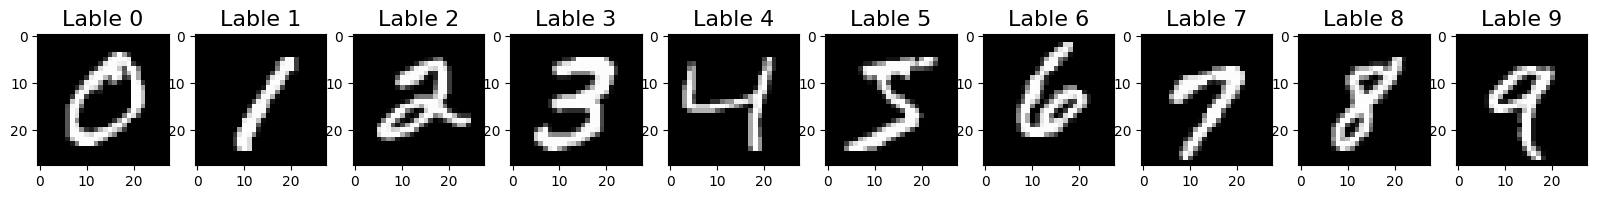

In [4]:
f, ax = plt.subplots(1, NB_CLASSES, figsize=(20,20))

for i in range(0, NB_CLASSES):
    sample = x_train[y_train == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title(f'Lable {i}', fontsize=16)

In [5]:
image_index = 300
for row in x_train[image_index]:
    for pixel in row:
        sys.stdout.write(f'{pixel:3d} ')
    sys.stdout.write('\n')

  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238 217  68   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254 254 232   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145 254 240  22   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 254 254 187 254 180   0   0   0   0 

### 1.4 One hot encoding the y data

In [6]:
print(y_train[0])

5


In [7]:
y_test_initial = y_test.copy()
y_train = keras.utils.to_categorical(y_train, NB_CLASSES)
y_test = keras.utils.to_categorical(y_test, NB_CLASSES)

In [8]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


### 1.5 Prepare x data

#### 1.5.1. Flatten the images _(28x28 vector -> 784x1)_

In [9]:
x_train = x_train.reshape(-1,784)
x_test = x_test.reshape(-1,784)
print(x_train.shape, y_train.shape)


(60000, 784) (60000, 10)


#### 1.5.2 Normalize the values _([0, 255] -> [0, 1])_

In [10]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


---

### 1.6. Functions definition

In [12]:
# Softmax
def softmax(x):
    x = x - np.max(x,axis=1,keepdims=True)
    expx = np.exp(x)
    return expx/np.sum(expx,axis=1,keepdims=True)

# Log loss function
# We add an epsilon just to avoid an error in the case where we get: np.log(0) -> -inf
def loss(Y,P):
    eps=1e-12
    return -np.mean(np.sum(Y*np.log(P+eps),axis=1))

def accuracy(Y, P):
    return np.mean(np.argmax(P, axis=1) == np.argmax(Y, axis=1))

def error_rate(Y, P):
    return 1.0 - accuracy(Y, P)

## 2. Classification model
### 2.1 Linear model

In [13]:
# Initialize weights and biases
np.random.seed(42)
A_lin = np.random.randn(NB_CLASSES, NB_INPUTS)*0.01 # random small weights
b_lin = np.zeros((1, NB_CLASSES)) # random biases

In [14]:
def gradient_descent(X,Y, P,n):
    dA =  (P - Y).T @ X / n
    db = sum((P - Y)) /n
    return dA, db

In [15]:
LEARNING_RATE = 0.5
prev_loss = float('inf')
max_iter = 2000 

In [16]:

loss_history_linear = []
accuracy_history_linear = []

i = 0
loss_threshold = 1e-4   

while i < max_iter:
    # Forward
    O = x_train @ A_lin.T + b_lin
    P = softmax(O)

    # Loss
    L = loss(y_train, P)
    #loss_history_linear.append(L)
    #accuracy_history_linear.append(accuracy(y_train, P))

    # Condition d'arrêt
    if abs(prev_loss - L) < loss_threshold:
        print(f"Convergence at iteration {i}: loss = {L:.6f}")
        break

    # Backprop and update
    dA, db = gradient_descent(x_train, y_train, P, x_train.shape[0])
    A_lin -= LEARNING_RATE * dA
    b_lin -= LEARNING_RATE * db

    #print(f'Loss at iteration {i}: {L:.4f}')
    prev_loss = L
    i += 1

Convergence at iteration 401: loss = 0.314165


### 2. Model with 1 hidden layer

In [17]:
def relu(x):
    return np.maximum(0.0, x)

def relu_derivative(x):
    # 1 if x > 0 else 0
    return (x > 0).astype(float)

In [18]:
p1 = 256 # number of neurons in the hidden layer
np.random.seed(42)

# initialize weights and biases for the hidden layer
# He initialization to avoid vanishing/exploding gradients
a1_h1 = np.random.randn(p1, NB_INPUTS) * np.sqrt(2. / p1) 
b1_h1 = np.zeros((1, p1))
a2_h1 = np.random.randn(NB_CLASSES, p1) * np.sqrt(2. / p1)
b2_h1 = np.zeros((1, NB_CLASSES))

print(f'a1_h1.shape: {a1_h1.shape} | b1_h1.shape: {b1_h1.shape}')
print(f'a2_h1.shape: {a2_h1.shape} | b2_h1.shape: {b2_h1.shape}')

a1_h1.shape: (256, 784) | b1_h1.shape: (1, 256)
a2_h1.shape: (10, 256) | b2_h1.shape: (1, 10)


In [19]:
loss_h1_history = []
accuracy_h1_history = []

prev_loss = float('inf')
i = 0

while i < max_iter:
    # Forward
    O1 = x_train @ a1_h1.T + b1_h1
    Z1 = relu(O1)
    O2 = Z1 @ a2_h1.T + b2_h1
    P  = softmax(O2)

    L = loss(y_train, P)
    #loss_h1_history.append(L)
    #accuracy_h1_history.append(accuracy(y_train, P))

    # Condition d'arrêt
    if abs(prev_loss - L) < loss_threshold:
        print(f"Convergence at iteration {i}: loss = {L:.6f}")
        break

    # Backprop
    dO2 = (P - y_train) / x_train.shape[0]
    da2_h1 = dO2.T @ Z1
    db2_h1 = np.sum(dO2, axis=0, keepdims=True)

    dZ1 = dO2 @ a2_h1 * relu_derivative(O1)
    da1_h1 = dZ1.T @ x_train
    db1_h1 = np.sum(dZ1, axis=0, keepdims=True)

    a2_h1 -= LEARNING_RATE * da2_h1
    b2_h1 -= LEARNING_RATE * db2_h1
    a1_h1 -= LEARNING_RATE * da1_h1
    b1_h1 -= LEARNING_RATE * db1_h1

    
    #print(f'Loss at iteration {i}: {L:.4f}')
    prev_loss = L
    i += 1
else:
    print(f"Max iterations reached ({max_iter}) without convergence")

Convergence at iteration 685: loss = 0.095486


### 2. Model with 2 hidden layers

In [20]:
p1 = 256 # number of neurons in the hidden layer
p2 = 128 # number of neurons in the second hidden layer
np.random.seed(42)

# initialize weights and biases for the hidden layer
# He initialization to avoid vanishing/exploding gradients
a1_h2 = np.random.randn(p1, NB_INPUTS) * np.sqrt(2. / p1) 
b1_h2 = np.zeros((1, p1))
a2_h2 = np.random.randn(p2, p1) * np.sqrt(2. / p1)
b2_h2 = np.zeros((1, p2))
a3_h2 = np.random.randn(NB_CLASSES, p2) * np.sqrt(2. / p2)
b3_h2 = np.zeros((1, NB_CLASSES))

print(f'a1_h2.shape: {a1_h2.shape} | b1_h2.shape: {b1_h2.shape}')
print(f'a2_h2.shape: {a2_h2.shape} | b2_h2.shape: {b2_h2.shape}')
print(f'a3_h2.shape: {a3_h2.shape} | b3_h2.shape: {b3_h2.shape}')

a1_h2.shape: (256, 784) | b1_h2.shape: (1, 256)
a2_h2.shape: (128, 256) | b2_h2.shape: (1, 128)
a3_h2.shape: (10, 128) | b3_h2.shape: (1, 10)


In [21]:
loss_h2_history = []
accuracy_h2_history = []

loss_threshold = 1e-5
prev_loss = float('inf')
max_iter = 2000
i = 0

while i < max_iter:
    # Forward
    O1 = x_train @ a1_h2.T + b1_h2
    Z1 = relu(O1)

    O2 = Z1 @ a2_h2.T + b2_h2
    Z2 = relu(O2)

    O3 = Z2 @ a3_h2.T + b3_h2
    P  = softmax(O3)

    L = loss(y_train, P)
    #loss_h2_history.append(L)
    #accuracy_h2_history.append(accuracy(y_train, P))

    # Stopping condition
    if abs(prev_loss - L) < loss_threshold:
        print(f"Convergence reached at iteration {i}: loss = {L:.6f}")
        break

    # Backprop layer 3
    dO3 = (P - y_train) / x_train.shape[0]
    da3_h2 = dO3.T @ Z2
    db3_h2 = np.sum(dO3, axis=0, keepdims=True)

    # Backprop layer 2
    dZ2 = dO3 @ a3_h2 * relu_derivative(O2)
    da2_h2 = dZ2.T @ Z1
    db2_h2 = np.sum(dZ2, axis=0, keepdims=True)

    # Backprop layer 1
    dZ1 = dZ2 @ a2_h2 * relu_derivative(O1)
    da1_h2 = dZ1.T @ x_train
    db1_h2 = np.sum(dZ1, axis=0, keepdims=True)

    a3_h2 -= LEARNING_RATE * da3_h2;  
    b3_h2 -= LEARNING_RATE * db3_h2
    a2_h2 -= LEARNING_RATE * da2_h2;  
    b2_h2 -= LEARNING_RATE * db2_h2
    a1_h2 -= LEARNING_RATE * da1_h2;  
    b1_h2 -= LEARNING_RATE * db1_h2

    #print(f'Loss at iteration {i}: {L:.4f}')
    prev_loss = L
    i += 1
else:
    print(f"Max iterations reached ({max_iter}) without convergence")

Convergence reached at iteration 1921: loss = 0.009364


## 3. Model comparison : evaluation, error analysis and discussion

### 3.1 Error rate 
#### 3.1.1 Error rate on training set

In [22]:
# Functions to compute the activations of the hidden layers
def activation_hidden_layer_h1(X):
    Z1 = relu(X @ a1_h1.T + b1_h1) # hidden layer activation
    return softmax(Z1 @ a2_h1.T + b2_h1)

def activation_hidden_layer_h2(X):
    Z1 = relu(X @ a1_h2.T + b1_h2) # first hidden layer activation
    Z2 = relu(Z1 @ a2_h2.T + b2_h2) # second hidden layer activation
    return softmax(Z2 @ a3_h2.T + b3_h2)

In [24]:
error_train = {}

# Prediction on the training set
pred_train_lin  = softmax(x_train @ A_lin.T + b_lin) # predicted class by the linear model
pred_train_h1   = activation_hidden_layer_h1(x_train) # predicted class by the 1 hidden layer model

# Linear model
error_train['Linear'] = error_rate(y_train, pred_train_lin)

# 1 hidden layer
error_train['1HL'] = error_rate(y_train, pred_train_h1)

# 2 hidden layers
error_train['2HL'] = error_rate(y_train, activation_hidden_layer_h2(x_train))

print(f"Linear model error - Train error: {error_train['Linear']*100:.2f}% ")
print(f"1 hidden layer error - Train error: {error_train['1HL']*100:.2f}%")
print(f"2 hidden layers error - Train error: {error_train['2HL']*100:.2f}%")

Linear model error - Train error: 8.71% 
1 hidden layer error - Train error: 2.59%
2 hidden layers error - Train error: 0.06%


#### 3.1.2 Error rate on test set 

In [25]:
error_test = {}
# Prediction on the test set
pred_test_lin  = softmax(x_test @ A_lin.T + b_lin) # predicted class by the linear model
pred_test_h1   = activation_hidden_layer_h1(x_test) # predicted class by the 1 hidden layer model

# Linear model
error_test['Linear'] = error_rate(y_test, pred_test_lin)

# 1 hidden layer
error_test['1HL'] = error_rate(y_test, pred_test_h1)

# 2 hidden layers
error_test['2HL'] = error_rate(y_test, activation_hidden_layer_h2(x_test))

print(f"Linear model error - Test error: {error_test['Linear']*100:.2f}% ")
print(f"1 hidden layer error - Test error: {error_test['1HL']*100:.2f}%")
print(f"2 hidden layers error - Test error: {error_test['2HL']*100:.2f}%")

Linear model error - Test error: 8.34% 
1 hidden layer error - Test error: 3.39%
2 hidden layers error - Test error: 2.22%


#### 3.1.3 Error rate comparison

In [26]:
models = ['Linear', '1HL', '2HL']
    
# print result under table format
print(f"{'Model':<20} {'Train error':>22} {'Test error':>22}")
print("-" * 75)

# print results
for i in range(len(models)):
    print(f"{models[i]:<20} {error_train[models[i]]*100:>20.2f}% {error_test[models[i]]*100:>20.2f}%")


Model                           Train error             Test error
---------------------------------------------------------------------------
Linear                               8.71%                 8.34%
1HL                                  2.59%                 3.39%
2HL                                  0.06%                 2.22%


### 3.2 Miss classified digits & explanation of the error
#### 3.2.1 Ambigous digit

In [27]:
true_labels = y_test_initial

# Prediction class
pred_lin = np.argmax(pred_test_lin, axis=1) # (10000,) int between 0-9
pred_h1  = np.argmax(pred_test_h1,  axis=1) # (10000,) int between 0-9

# Indices of missclassified images
erreurs_lin = np.where(pred_lin != true_labels)[0]
erreurs_h1  = np.where(pred_h1  != true_labels)[0]

print(f"Linear model : {len(erreurs_lin)} errors out of {len(true_labels)}")
print(f"MLP 1 hidden layer : {len(erreurs_h1)} errors out of {len(true_labels)}")

# Count errors per class
error_count_lin = np.zeros(NB_CLASSES, dtype=int)
error_count_h1  = np.zeros(NB_CLASSES, dtype=int)

for i in erreurs_lin:
    error_count_lin[true_labels[i]] += 1 

for i in erreurs_h1:
    error_count_h1[true_labels[i]] += 1

# Print errors per class
for i in range(NB_CLASSES):
    print(f"Class {i}: Linear model: {error_count_lin[i]} errors, 1 hidden layer: {error_count_h1[i]} errors")

Linear model : 834 errors out of 10000
MLP 1 hidden layer : 339 errors out of 10000
Class 0: Linear model: 20 errors, 1 hidden layer: 12 errors
Class 1: Linear model: 30 errors, 1 hidden layer: 14 errors
Class 2: Linear model: 128 errors, 1 hidden layer: 38 errors
Class 3: Linear model: 92 errors, 1 hidden layer: 28 errors
Class 4: Linear model: 66 errors, 1 hidden layer: 35 errors
Class 5: Linear model: 125 errors, 1 hidden layer: 37 errors
Class 6: Linear model: 48 errors, 1 hidden layer: 36 errors
Class 7: Linear model: 89 errors, 1 hidden layer: 41 errors
Class 8: Linear model: 122 errors, 1 hidden layer: 42 errors
Class 9: Linear model: 114 errors, 1 hidden layer: 56 errors


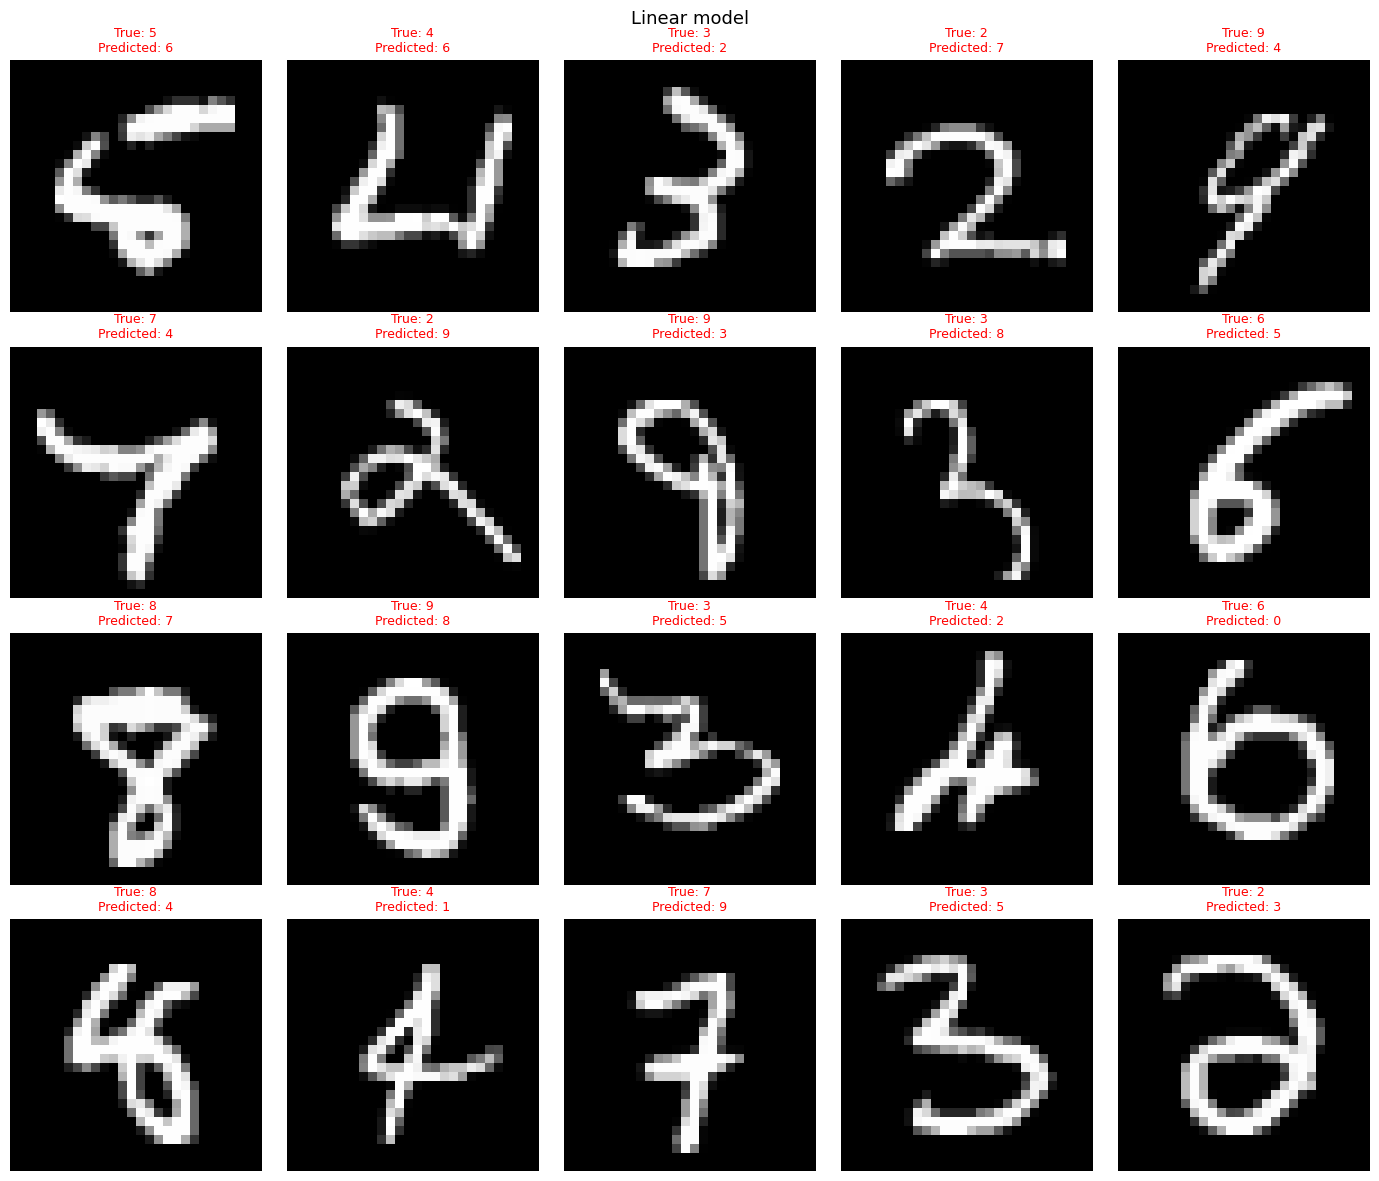

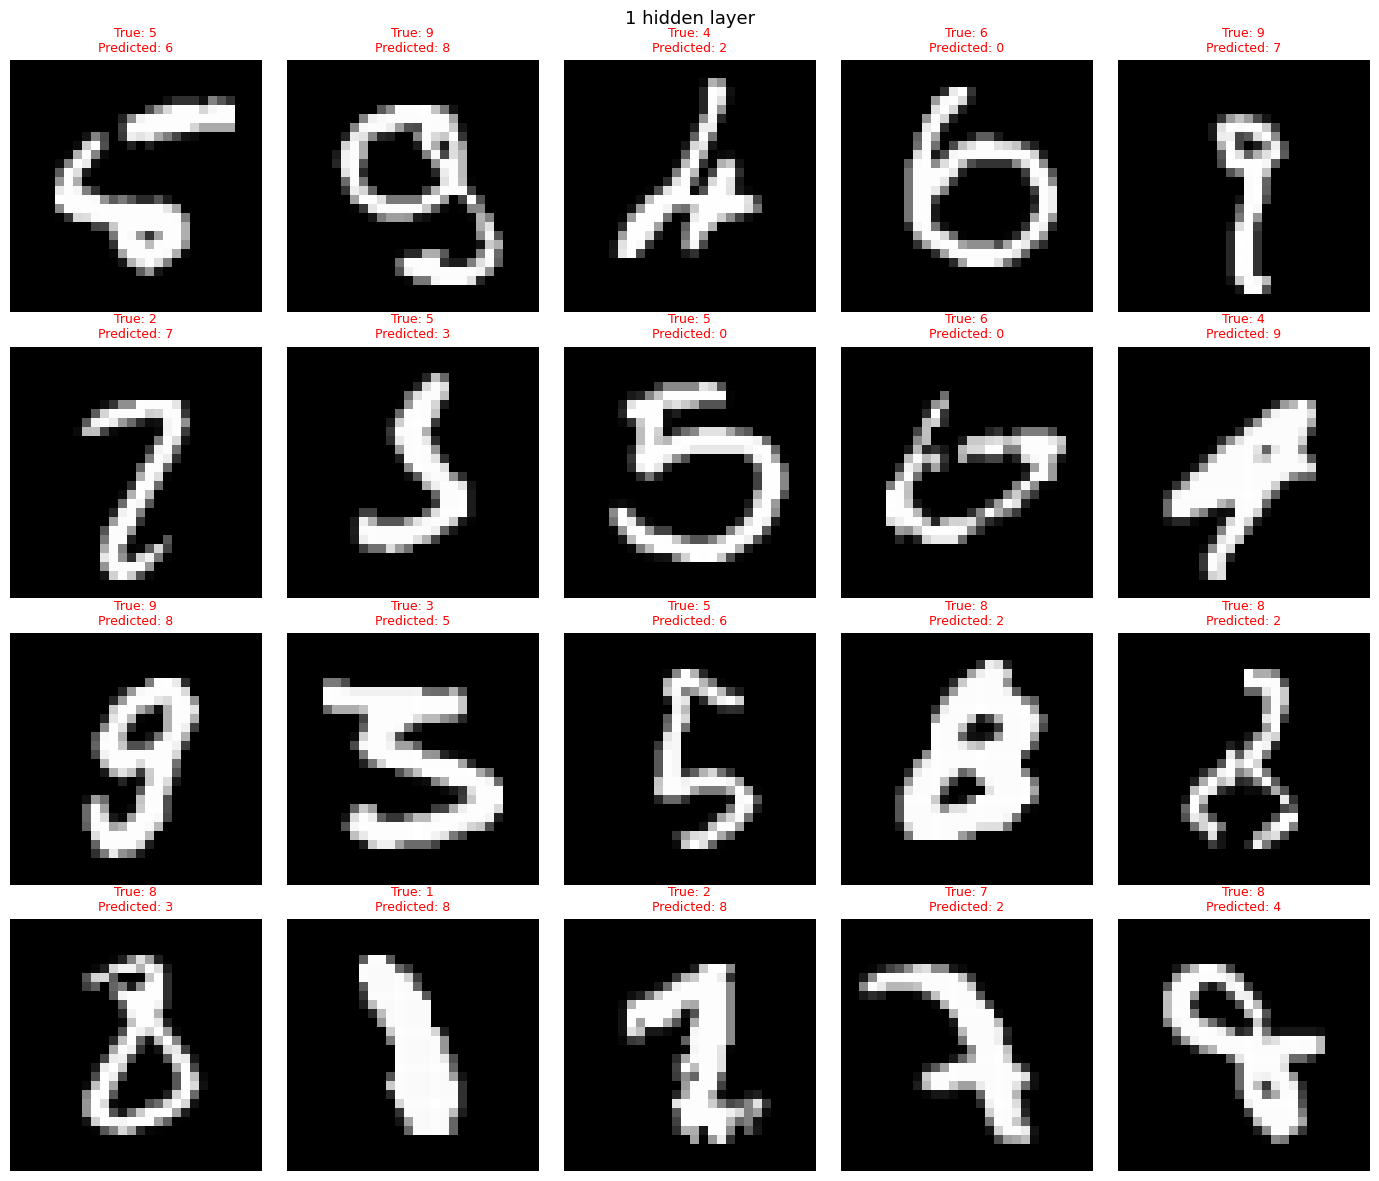

In [28]:
# sample of 20 misclassified images for each model
def display_errors(erreurs_idx, x_test, true_labels, pred, titre, n_show=20):

    fig, axes = plt.subplots(4, 5, figsize=(14, 12))
    axes = axes.ravel()
    for j, i in enumerate(erreurs_idx[:n_show]):
        i = int(i)                          
        img = x_test[i].reshape(28, 28)
        axes[j].imshow(img, cmap='gray')
        axes[j].set_title(
            f'True: {true_labels[i]}\nPredicted: {pred[i]}',fontsize=9, color='red')
        axes[j].axis('off')
    plt.suptitle(titre, fontsize=13)
    plt.tight_layout()
    plt.show()

display_errors(erreurs_lin, x_test, true_labels, pred_lin, "Linear model")
display_errors(erreurs_h1,  x_test, true_labels, pred_h1,  "1 hidden layer")

#### 3.2.2 Atypical Handwriting

In [29]:
# Reduce dimension from 784 -> 2
pca_reduced =  PCA(n_components = 2)
X_pca = pca_reduced.fit_transform(x_test)

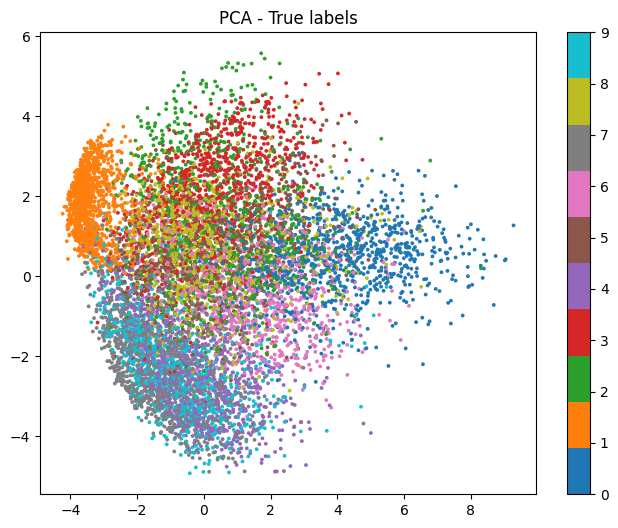

In [30]:
# each color = 1 digit, clusters overlapping each other => ambiguous digit
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=true_labels, cmap='tab10', s=3)
plt.colorbar()
plt.title("PCA - True labels")
plt.show()

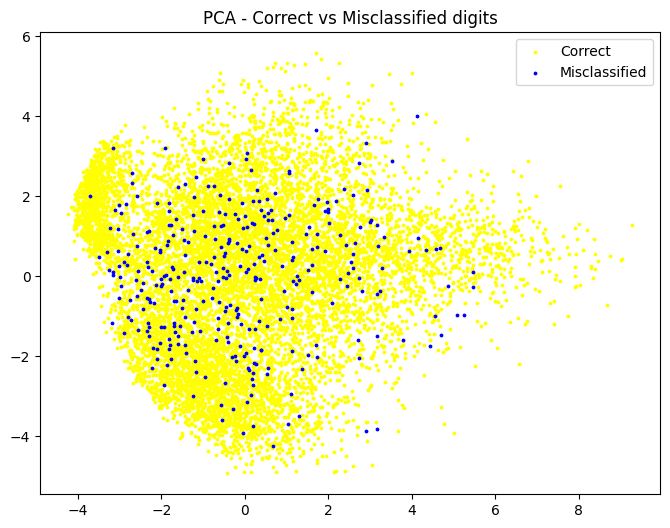

In [31]:
# the errors that are overlapping centrally are susceptible to be the ambiguous digits and the one isolated corresponds to the atypical handwriting
correct = (pred_h1 == true_labels)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[correct,0], X_pca[correct,1], c='yellow', s=3, label='Correct')
plt.scatter(X_pca[~correct,0], X_pca[~correct,1], c='blue', s=3, label='Misclassified')

plt.legend()
plt.title("PCA - Correct vs Misclassified digits")
plt.show()

In [ ]:
# plt.plot(accuracy_lin_history, label="Linear")
# plt.plot(accuracy_h1_history, label="MLP - 1 Hidden Layer")
# plt.plot(accuracy_h2_history, label="MLP - 2 Hidden Layers")
# plt.legend()
# plt.title("Training accuracy comparison")
# plt.show()